## CMS-295


---
### 1#Transformer
* Background on NLP and tasks
* Tokenization
* Embeddings
* Word2vec, RNN, LSTM
* Attention mechanism
* Transformer architecture

---
### 2#transfer based model and tricks
* Attention approximation
* MHA, MQA, GQA
* Position embeddings (regular, learned)
* RoPE and applications
* Transformer-based architectures
* BERT and its derivatives

---
### 3#Large language models
* Definition and architecture
* Mixture of experts
* Context length, temperature
* Sampling strategies
* Prompting, in-context learning
* Chain of thought
* Self-consistency
---
### 4#LLM training
* Pretraining
* Quantization
* Hardware optimization
* Supervised finetuning (SFT)
* Parameter-efficient finetuning (LoRA)

---
### 5#LLM tuning
1. Preference tuning
1. RLHF overview
1. Reward modeling
1. RL approaches (PPO and variants)
1. DPO

### 6#LLM reasoning
* Reasoning models
* RL for reasoning
* GRPO
* Scaling

### 7#Agentic LLMs
* Retrieval-augmented generation
* Advanced RAG techniques
* Function calling
* Agents
* ReAct framework

### 8#Evaluation of LLMs
* LLM-as-a-judge overview
* Best practices and benefits
* Biases and pitfalls
* Multimodality
* VLM-as-a-judge

### 9#Conclusion & future trends
* Convergence of methods
* Current and future trends
* Closing thoughts

## RL Course by David Silver


### 1#Introduction to Reinforcement
Learning
1. Admin
2. About Reinforcement Learning
3. The Reinforcement Learning Problem
4. Inside An RL Agent
5. Problems within Reinforcement Learning
---
### 2#Markov Decision Process
1. Markov Processes
2. Markov Reward Processes
3. Markov Decision Processes
4. Extensions to MDPs
---
### 3#Planning by Dynamic Programming
1. Introduction
2. Policy Evaluation
3. Policy Iteration
4. Value Iteration
5. Extensions to Dynamic Programming
6. Contraction Mapping
---
### 4#Model-Free Prediction
1. Introduction
2. Monte-Carlo Learning
3. Temporal-Difference Learning
4. TD(λ)
---
### 5#Model-Free Control
1. Introduction
2. On-Policy Monte-Carlo Control
3. On-Policy Temporal-Difference Learning
4. Off-Policy Learning
5. Summary

---
### 6#Value Function Appromixation
1. Introduction
2. Incremental Methods
3. Batch Methods

---
### 7#Policy Gradient Methods
1. Introduction
2. Finite Difference Policy Gradient
3. Monte-Carlo Policy Gradient
4. Actor-Critic Policy Gradient

---
### 8#Integrating Learning and Method
1. Introduction
2. Model-Based Reinforcement Learning
3. Integrated Architectures
4. Simulation-Based Search

---
### 9#Expoloration and Exploitations
1. Introduction
2. Multi-Armed Bandits
3. Contextual Bandits
4. MDPs

---
### 10#Case Study
1. State of the Art
2. Game Theory
3. Minimax Search
4. Self-Play Reinforcement Learning
5. Combining Reinforcement Learning and Minimax Search
6. Reinforcement Learning in Imperfect-Information Games
7. Conclusions

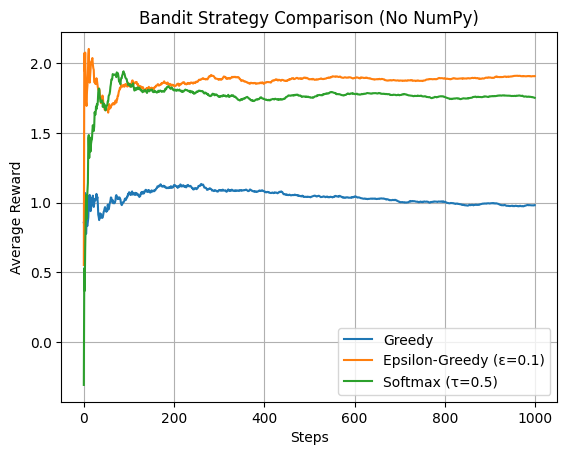

In [ ]:
import random
import math
import matplotlib.pyplot as plt

random.seed(42)

# --- Environment ---
true_means = [1.0, 1.5, 2.0]  # true rewards
n_actions = len(true_means)

def pull(action):
    return random.gauss(true_means[action], 1.0)

# --- Strategies ---

def greedy(Q):
    return Q.index(max(Q))

def epsilon_greedy(Q, epsilon):
    if random.random() < epsilon:
        return random.randint(0, len(Q) - 1)
    return greedy(Q)

def softmax(Q, tau):
    exp_vals = [math.exp(q / tau) for q in Q]
    total = sum(exp_vals)
    probs = [v / total for v in exp_vals]

    r = random.random()
    cumulative = 0
    for i, p in enumerate(probs):
        cumulative += p
        if r < cumulative:
            return i

    return len(Q) - 1  # fallback

# --- Simulation ---
def run(strategy, steps=1000, epsilon=0.1, tau=0.5):
    Q = [0.0] * n_actions
    N = [0] * n_actions

    rewards = []
    avg_rewards = []

    total_reward = 0

    for t in range(steps):
        if strategy == "greedy":
            action = greedy(Q)
        elif strategy == "epsilon":
            action = epsilon_greedy(Q, epsilon)
        elif strategy == "softmax":
            action = softmax(Q, tau)

        reward = pull(action)

        # Update counts
        N[action] += 1

        # Incremental mean update
        Q[action] += (reward - Q[action]) / N[action]

        total_reward += reward
        avg_rewards.append(total_reward / (t + 1))

    return avg_rewards

# --- Run experiments ---
steps = 1000

greedy_rewards = run("greedy", steps)
epsilon_rewards = run("epsilon", steps, epsilon=0.1)
softmax_rewards = run("softmax", steps, tau=0.5)

# --- Plot ---
plt.plot(greedy_rewards, label="Greedy")
plt.plot(epsilon_rewards, label="Epsilon-Greedy (ε=0.1)")
plt.plot(softmax_rewards, label="Softmax (τ=0.5)")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Bandit Strategy Comparison (No NumPy)")
plt.legend()
plt.grid()
plt.show()

## Embedding

Token embeddings shape: (2, 10, 8)
Positional encodings shape: (10, 8)
Final embeddings shape: (2, 10, 8)

Relative position matrix shape: (10, 10, 8)
Relative encoding for distance 2: [ 0.04180399  0.01940353  0.0259185  -0.00194416]

Original embedding: [-1.62987319 -1.06474024  0.40813484  1.7694007 ]
Rotated embedding: [-1.62987319 -1.06474024  0.40813484  1.7694007 ]


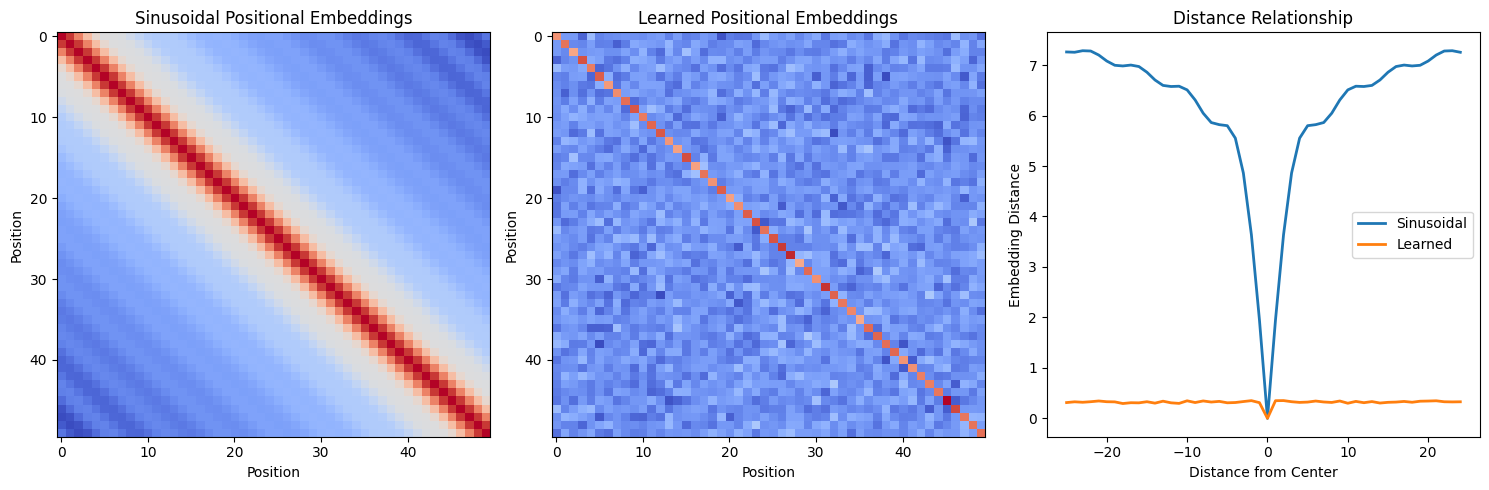


Properties of Sinusoidal Embeddings:
Dot product (positions 10, 15): 189.5967
Dot product (positions 15, 20): 189.5967
Dot product (positions 10, 20): 173.7897


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class PositionalEmbedding:
    """Base class for positional embeddings"""
    def __init__(self, max_seq_len, embedding_dim):
        self.max_seq_len = max_seq_len
        self.embedding_dim = embedding_dim
        self.positional_encodings = None

    def get_positional_encodings(self):
        """Get positional encodings matrix"""
        raise NotImplementedError

    def visualize(self, figsize=(12, 8)):
        """Visualize positional encodings"""
        plt.figure(figsize=figsize)
        plt.imshow(self.positional_encodings, aspect='auto', cmap='viridis')
        plt.colorbar(label='Encoding Value')
        plt.xlabel('Embedding Dimension')
        plt.ylabel('Position')
        plt.title(f'{self.__class__.__name__}')
        plt.show()


class SinusoidalPositionalEmbedding(PositionalEmbedding):
    """
    Sinusoidal positional embeddings from "Attention is All You Need"
    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """

    def __init__(self, max_seq_len=100, embedding_dim=512):
        super().__init__(max_seq_len, embedding_dim)
        self.positional_encodings = self._create_sinusoidal_encodings()

    def _create_sinusoidal_encodings(self):
        """Create sinusoidal positional encodings"""
        positional_encodings = np.zeros((self.max_seq_len, self.embedding_dim))

        # Create position indices
        positions = np.arange(self.max_seq_len).reshape(-1, 1)

        # Create division terms
        div_term = np.exp(np.arange(0, self.embedding_dim, 2) *
                         -(np.log(10000.0) / self.embedding_dim))

        # Apply sine to even indices
        positional_encodings[:, 0::2] = np.sin(positions * div_term)

        # Apply cosine to odd indices
        positional_encodings[:, 1::2] = np.cos(positions * div_term)

        return positional_encodings

    def __call__(self, positions):
        """Get encodings for specific positions"""
        return self.positional_encodings[positions]

    def get_encoding_for_position(self, position):
        """Get encoding vector for a single position"""
        return self.positional_encodings[position]


class LearnedPositionalEmbedding(PositionalEmbedding):
    """
    Learned positional embeddings - treat positions as learnable parameters
    """

    def __init__(self, max_seq_len=100, embedding_dim=512, seed=42):
        super().__init__(max_seq_len, embedding_dim)
        np.random.seed(seed)
        # Initialize with small random values
        self.positional_encodings = np.random.randn(max_seq_len, embedding_dim) * 0.02

    def update_encodings(self, gradients, learning_rate=0.001):
        """Update positional encodings with gradients (for training)"""
        self.positional_encodings -= learning_rate * gradients

    def __call__(self, positions):
        """Get encodings for specific positions"""
        return self.positional_encodings[positions]

    def get_encoding_for_position(self, position):
        """Get encoding vector for a single position"""
        return self.positional_encodings[position]


class RelativePositionalEmbedding:
    """
    Relative positional embeddings for capturing relative position information
    """

    def __init__(self, max_relative_position=10, embedding_dim=512):
        self.max_relative_position = max_relative_position
        self.embedding_dim = embedding_dim
        self.relative_encodings = self._create_relative_encodings()

    def _create_relative_encodings(self):
        """
        Create relative position embeddings for distances from -max to +max
        """
        num_relative_positions = 2 * self.max_relative_position + 1
        # Initialize random embeddings for relative positions
        return np.random.randn(num_relative_positions, self.embedding_dim) * 0.02

    def get_relative_encoding(self, distance):
        """Get encoding for a specific relative distance"""
        # Clip distance to valid range
        distance = np.clip(distance, -self.max_relative_position,
                          self.max_relative_position)
        # Convert distance to index (0-based)
        idx = distance + self.max_relative_position
        return self.relative_encodings[idx]

    def get_relative_matrix(self, seq_len):
        """Get matrix of relative position encodings for all pairs"""
        relative_matrix = np.zeros((seq_len, seq_len, self.embedding_dim))

        for i in range(seq_len):
            for j in range(seq_len):
                distance = j - i
                relative_matrix[i, j] = self.get_relative_encoding(distance)

        return relative_matrix


class RotaryPositionalEmbedding:
    """
    Rotary Position Embedding (RoPE) - rotates embeddings based on position
    Improves relative position information while maintaining absolute position
    """

    def __init__(self, embedding_dim, max_seq_len=100):
        self.embedding_dim = embedding_dim
        self.max_seq_len = max_seq_len
        self.rotation_matrices = self._create_rotation_matrices()

    def _create_rotation_matrices(self):
        """Create rotation matrices for each position"""
        rotations = []

        for pos in range(self.max_seq_len):
            # Create rotation matrix for this position
            rotation_matrix = self._get_rotation_matrix(pos)
            rotations.append(rotation_matrix)

        return rotations

    def _get_rotation_matrix(self, position):
        """Get rotation matrix for a specific position"""
        # Create rotation matrices for each pair of dimensions
        rotation_matrix = np.eye(self.embedding_dim)

        # Apply 2D rotations to consecutive dimensions
        for i in range(0, self.embedding_dim, 2):
            if i + 1 < self.embedding_dim:
                theta = position / (10000 ** (2 * (i // 2) / self.embedding_dim))
                cos_theta = np.cos(theta)
                sin_theta = np.sin(theta)

                # Create 2x2 rotation matrix
                rot = np.array([[cos_theta, -sin_theta],
                               [sin_theta, cos_theta]])

                # Ensure indices are within bounds
                if i + 1 < self.embedding_dim:
                    rotation_matrix[i:i+2, i:i+2] = rot

        return rotation_matrix

    def rotate_embeddings(self, embeddings, positions):
        """Apply rotary embedding to input embeddings"""
        rotated_embeddings = np.zeros_like(embeddings)

        for i, (embedding, pos) in enumerate(zip(embeddings, positions)):
            rotated_embeddings[i] = self.rotation_matrices[pos] @ embedding

        return rotated_embeddings


class PositionalEncodingWithDropout:
    """
    Positional encoding with dropout for regularization
    """

    def __init__(self, positional_encoder, dropout_rate=0.1):
        self.positional_encoder = positional_encoder
        self.dropout_rate = dropout_rate
        self.training = True

    def apply_dropout(self, x):
        """Apply dropout to the input"""
        if not self.training or self.dropout_rate == 0:
            return x

        mask = np.random.binomial(1, 1 - self.dropout_rate, x.shape)
        return x * mask / (1 - self.dropout_rate)

    def add_to_embeddings(self, token_embeddings, positions):
        """Add positional encodings to token embeddings with dropout"""
        positional_encodings = self.positional_encoder(positions)

        # Apply dropout to positional encodings
        if self.dropout_rate > 0:
            positional_encodings = self.apply_dropout(positional_encodings)

        return token_embeddings + positional_encodings


def visualize_comparison():
    """Compare different positional embedding methods"""

    # Create different embeddings
    max_len = 50
    embed_dim = 128

    sinusoidal = SinusoidalPositionalEmbedding(max_len, embed_dim)
    learned = LearnedPositionalEmbedding(max_len, embed_dim)

    # Plot correlation heatmaps for different embeddings
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Sinusoidal embeddings
    axes[0].imshow(sinusoidal.positional_encodings @ sinusoidal.positional_encodings.T,
                   cmap='coolwarm', aspect='auto')
    axes[0].set_title('Sinusoidal Positional Embeddings')
    axes[0].set_xlabel('Position')
    axes[0].set_ylabel('Position')

    # Learned embeddings
    axes[1].imshow(learned.positional_encodings @ learned.positional_encodings.T,
                   cmap='coolwarm', aspect='auto')
    axes[1].set_title('Learned Positional Embeddings')
    axes[1].set_xlabel('Position')
    axes[1].set_ylabel('Position')

    # Compare distance relationships
    distances = np.arange(-max_len//2, max_len//2)
    sinusoidal_distances = []
    learned_distances = []

    center = max_len // 2
    center_encoding_sin = sinusoidal.positional_encodings[center]
    center_encoding_learn = learned.positional_encodings[center]

    for d in distances:
        if 0 <= center + d < max_len:
            dist_sin = np.linalg.norm(center_encoding_sin -
                                      sinusoidal.positional_encodings[center + d])
            dist_learn = np.linalg.norm(center_encoding_learn -
                                       learned.positional_encodings[center + d])
            sinusoidal_distances.append(dist_sin)
            learned_distances.append(dist_learn)

    axes[2].plot(distances, sinusoidal_distances, label='Sinusoidal', linewidth=2)
    axes[2].plot(distances, learned_distances, label='Learned', linewidth=2)
    axes[2].set_title('Distance Relationship')
    axes[2].set_xlabel('Distance from Center')
    axes[2].set_ylabel('Embedding Distance')
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def practical_usage_example():
    """Demonstrate practical usage of positional embeddings"""

    # Setup parameters
    batch_size = 2
    seq_len = 10
    embed_dim = 8
    max_positions = 20

    # Create dummy token embeddings
    token_embeddings = np.random.randn(batch_size, seq_len, embed_dim)

    # Create positional encoder
    pos_encoder = SinusoidalPositionalEmbedding(max_positions, embed_dim)

    # Add positional encodings
    positions = np.arange(seq_len)
    positional_encodings = pos_encoder(positions)

    # Add to token embeddings
    final_embeddings = token_embeddings + positional_encodings

    print("Token embeddings shape:", token_embeddings.shape)
    print("Positional encodings shape:", positional_encodings.shape)
    print("Final embeddings shape:", final_embeddings.shape)

    # Demonstrate relative positions
    rel_encoder = RelativePositionalEmbedding(max_relative_position=5, embedding_dim=embed_dim)
    relative_matrix = rel_encoder.get_relative_matrix(seq_len)

    print("\nRelative position matrix shape:", relative_matrix.shape)
    print("Relative encoding for distance 2:", rel_encoder.get_relative_encoding(2)[:4])

    # Demonstrate rotary embeddings
    rotary_encoder = RotaryPositionalEmbedding(embed_dim, max_positions)
    rotated_embeddings = rotary_encoder.rotate_embeddings(token_embeddings[0], positions)

    print("\nOriginal embedding:", token_embeddings[0, 0, :4])
    print("Rotated embedding:", rotated_embeddings[0, :4])

    return final_embeddings


if __name__ == "__main__":
    # Run practical example
    final_embeddings = practical_usage_example()

    # Visualize comparison
    visualize_comparison()

    # Additional properties of sinusoidal embeddings
    sinusoidal = SinusoidalPositionalEmbedding(50, 512)

    # Show that dot product depends only on distance
    pos_1 = sinusoidal.get_encoding_for_position(10)
    pos_2 = sinusoidal.get_encoding_for_position(15)
    pos_3 = sinusoidal.get_encoding_for_position(20)

    print(f"\nProperties of Sinusoidal Embeddings:")
    print(f"Dot product (positions 10, 15): {np.dot(pos_1, pos_2):.4f}")
    print(f"Dot product (positions 15, 20): {np.dot(pos_2, pos_3):.4f}")
    print(f"Dot product (positions 10, 20): {np.dot(pos_1, pos_3):.4f}")

In [ ]:
import numpy as np

class WordEmbeddingWithVocabulary:
    """Complete word embedding system with vocabulary mapping"""

    def __init__(self, vocab_size=1000, embedding_dim=512):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim

        # Create vocabulary mapping (index -> word)
        self.idx_to_word = {}
        self.word_to_idx = {}

        # Create word embeddings (learnable parameters)
        # In practice, these would be trained, here we initialize randomly
        np.random.seed(42)
        self.word_embeddings = np.random.randn(vocab_size, embedding_dim) * 0.02

    def build_vocabulary(self, words_list):
        """Build vocabulary from list of words"""
        for idx, word in enumerate(words_list):
            self.word_to_idx[word] = idx
            self.idx_to_word[idx] = word

    def get_word_from_idx(self, idx):
        """Get word from its index"""
        if idx in self.idx_to_word:
            return self.idx_to_word[idx]
        else:
            return f"<UNK_{idx}>"  # Unknown token

    def get_idx_from_word(self, word):
        """Get index from word"""
        return self.word_to_idx.get(word, -1)  # -1 for unknown

    def get_embedding(self, idx):
        """Get embedding vector for an index"""
        if 0 <= idx < self.vocab_size:
            return self.word_embeddings[idx]
        else:
            return np.zeros(self.embedding_dim)

    def get_word_embedding(self, word):
        """Get embedding vector for a word"""
        idx = self.get_idx_from_word(word)
        return self.get_embedding(idx) if idx != -1 else np.zeros(self.embedding_dim)


# Example 1: Basic word to index mapping
print("=" * 50)
print("EXAMPLE 1: Basic Mapping")
print("=" * 50)

# Create vocabulary
vocab_words = [
    "hello", "world", "this", "is", "a", "test",
    "sentence", "for", "positional", "embedding",
    "<PAD>", "<UNK>", "<START>", "<END>"
]

embedding_system = WordEmbeddingWithVocabulary(vocab_size=len(vocab_words), embedding_dim=8)
embedding_system.build_vocabulary(vocab_words)

# Show mapping
print("\nVocabulary Mapping:")
for idx, word in enumerate(vocab_words[:5]):  # Show first 5
    print(f"  Index {idx} -> '{word}'")

# Example sentence
sentence = ["hello", "world", "this", "is", "a", "test"]
print(f"\nSentence: {sentence}")

# Convert words to indices
indices = [embedding_system.get_idx_from_word(word) for word in sentence]
print(f"Indices: {indices}")

# Convert indices back to words
recovered_words = [embedding_system.get_word_from_idx(idx) for idx in indices]
print(f"Recovered words: {recovered_words}")


# Example 2: Complete pipeline with positional embeddings
print("\n" + "=" * 50)
print("EXAMPLE 2: Complete Pipeline with Positional Embeddings")
print("=" * 50)

class CompleteEmbeddingPipeline:
    """Complete pipeline: words -> indices -> embeddings + positional encodings"""

    def __init__(self, vocab, embedding_dim=8, max_seq_len=20):
        self.embedding_system = WordEmbeddingWithVocabulary(
            vocab_size=len(vocab),
            embedding_dim=embedding_dim
        )
        self.embedding_system.build_vocabulary(vocab)

        # Positional encoder
        self.pos_encoder = SinusoidalPositionalEmbedding(max_seq_len, embedding_dim)

    def words_to_embeddings(self, sentence):
        """Convert sentence to embeddings with positional information"""
        # Step 1: Convert words to indices
        indices = []
        for word in sentence:
            idx = self.embedding_system.get_idx_from_word(word)
            if idx == -1:
                idx = self.embedding_system.get_idx_from_word("<UNK>")
            indices.append(idx)

        # Step 2: Get word embeddings
        word_embeddings = np.array([self.embedding_system.get_embedding(idx)
                                   for idx in indices])

        # Step 3: Add positional encodings
        positions = np.arange(len(sentence))
        positional_encodings = self.pos_encoder(positions)

        # Step 4: Combine
        final_embeddings = word_embeddings + positional_encodings

        return {
            'words': sentence,
            'indices': indices,
            'word_embeddings': word_embeddings,
            'positional_encodings': positional_encodings,
            'final_embeddings': final_embeddings
        }

    def embeddings_to_words(self, final_embeddings, indices=None):
        """Recover words from embeddings (simplified - would need full model)"""
        # In a real scenario, you'd use the model's output layer
        # Here we just return from indices if provided
        if indices is not None:
            return [self.embedding_system.get_word_from_idx(idx) for idx in indices]
        return None

    def visualize_embeddings(self, result):
        """Visualize the embedding components"""
        print(f"\nSentence: {' '.join(result['words'])}")
        print(f"Indices: {result['indices']}")
        print(f"\nWord Embeddings shape: {result['word_embeddings'].shape}")
        print(f"Positional Encodings shape: {result['positional_encodings'].shape}")
        print(f"Final Embeddings shape: {result['final_embeddings'].shape}")

        # Show first few dimensions
        print("\nFirst 3 dimensions of each component:")
        for i, word in enumerate(result['words']):
            print(f"  '{word}':")
            print(f"    Word Emb: {result['word_embeddings'][i, :3]}")
            print(f"    Pos Emb:  {result['positional_encodings'][i, :3]}")
            print(f"    Final:    {result['final_embeddings'][i, :3]}")


# Create and use the complete pipeline
pipeline = CompleteEmbeddingPipeline(vocab_words, embedding_dim=8, max_seq_len=20)

# Example sentence
test_sentence = ["hello", "world", "positional", "embedding"]
result = pipeline.words_to_embeddings(test_sentence)

# Display results
pipeline.visualize_embeddings(result)

# Recover words from indices
recovered = pipeline.embeddings_to_words(None, result['indices'])
print(f"\nRecovered sentence: {' '.join(recovered)}")


# Example 3: Batch processing and attention visualization
print("\n" + "=" * 50)
print("EXAMPLE 3: Batch Processing with Attention")
print("=" * 50)

class TransformerBlock:
    """Simple transformer block to show word-level attention"""

    def __init__(self, embedding_dim=8):
        self.embedding_dim = embedding_dim
        # Simplified attention weights (would be learned)
        self.attention_weights = None

    def compute_attention(self, embeddings):
        """Compute attention weights between words"""
        seq_len = embeddings.shape[0]
        attention = np.zeros((seq_len, seq_len))

        # Simplified attention: dot product similarity
        for i in range(seq_len):
            for j in range(seq_len):
                attention[i, j] = np.dot(embeddings[i], embeddings[j])

        # Softmax
        attention = np.exp(attention) / np.sum(np.exp(attention), axis=1, keepdims=True)
        self.attention_weights = attention
        return attention

    def get_most_attended_words(self, attention_matrix, words):
        """Find which words attend most to each other"""
        result = []
        for i, word in enumerate(words):
            # Find top 2 attended positions for this word
            top_indices = np.argsort(attention_matrix[i])[-2:][::-1]
            attended_words = [(words[j], attention_matrix[i, j]) for j in top_indices if j != i]
            result.append((word, attended_words))
        return result


# Process multiple sentences
sentences = [
    ["hello", "world"],
    ["this", "is", "a", "test"],
    ["positional", "embedding", "example"]
]

transformer = TransformerBlock(embedding_dim=8)

for sentence in sentences:
    print(f"\nProcessing: {sentence}")

    # Get embeddings
    result = pipeline.words_to_embeddings(sentence)

    # Compute attention
    attention = transformer.compute_attention(result['final_embeddings'])

    # Show attention patterns
    print("Attention Matrix (simplified):")
    print(np.round(attention, 2))

    # Show most attended pairs
    attended_pairs = transformer.get_most_attended_words(attention, sentence)
    for word, attended in attended_pairs:
        if attended:
            print(f"  '{word}' attends most to: {attended[0][0]} (weight: {attended[0][1]:.2f})")


# Example 4: Reverse mapping - finding closest word to an embedding
print("\n" + "=" * 50)
print("EXAMPLE 4: Finding Closest Word to an Embedding")
print("=" * 50)

def find_closest_word(embedding, embedding_system, top_k=3):
    """Find the K closest words to a given embedding vector"""
    similarities = []

    for idx in range(embedding_system.vocab_size):
        word_emb = embedding_system.get_embedding(idx)
        # Cosine similarity
        sim = np.dot(embedding, word_emb) / (np.linalg.norm(embedding) * np.linalg.norm(word_emb) + 1e-8)
        similarities.append((idx, sim))

    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)

    # Return top K
    return [(embedding_system.get_word_from_idx(idx), sim) for idx, sim in similarities[:top_k]]

# Get embedding of a word and find similar words
test_word = "test"
word_idx = pipeline.embedding_system.get_idx_from_word(test_word)
word_embedding = pipeline.embedding_system.get_embedding(word_idx)

print(f"\nWord: '{test_word}'")
print(f"Embedding (first 5 dims): {word_embedding[:5]}")

print(f"\nMost similar words to '{test_word}':")
similar_words = find_closest_word(word_embedding, pipeline.embedding_system, top_k=3)
for word, sim in similar_words:
    print(f"  {word}: {sim:.4f}")

# Example with positional embedding combined
print(f"\nMost similar words to '{test_word}' with position 5 encoding:")
# Add positional encoding at position 5
pos_encoding = pipeline.pos_encoder.get_encoding_for_position(5)
combined = word_embedding + pos_encoding

similar_with_pos = find_closest_word(combined, pipeline.embedding_system, top_k=3)
for word, sim in similar_with_pos:
    print(f"  {word}: {sim:.4f}")

EXAMPLE 1: Basic Mapping

Vocabulary Mapping:
  Index 0 -> 'hello'
  Index 1 -> 'world'
  Index 2 -> 'this'
  Index 3 -> 'is'
  Index 4 -> 'a'

Sentence: ['hello', 'world', 'this', 'is', 'a', 'test']
Indices: [0, 1, 2, 3, 4, 5]
Recovered words: ['hello', 'world', 'this', 'is', 'a', 'test']

EXAMPLE 2: Complete Pipeline with Positional Embeddings

Sentence: hello world positional embedding
Indices: [0, 1, 8, 9]

Word Embeddings shape: (4, 8)
Positional Encodings shape: (4, 8)
Final Embeddings shape: (4, 8)

First 3 dimensions of each component:
  'hello':
    Word Emb: [ 0.00993428 -0.00276529  0.01295377]
    Pos Emb:  [0. 1. 0.]
    Final:    [0.00993428 0.99723471 0.01295377]
  'world':
    Word Emb: [-0.00938949  0.0108512  -0.00926835]
    Pos Emb:  [0.84147098 0.54030231 0.09983342]
    Final:    [0.8320815  0.55115351 0.09056506]
  'positional':
    Word Emb: [ 0.01625052  0.0271248  -0.0014402 ]
    Pos Emb:  [ 0.90929743 -0.41614684  0.19866933]
    Final:    [ 0.92554794 -0.38

1. Step one make Tokenization

In [ ]:
class SimpleTokenizer:

    def __init__(self):

        self.word_to_id = {
            "<UNK>": 0
        }

        self.id_to_word = {
            0: "<UNK>"
        }

    def fit(self, text):

        tokens = text.split()

        for token in tokens:

            if token not in self.word_to_id:

                token_id = len(self.word_to_id)

                self.word_to_id[token] = token_id
                self.id_to_word[token_id] = token

    def encode(self, text):

        tokens = text.split()

        ids = []

        for token in tokens:

            if token in self.word_to_id:
                ids.append(self.word_to_id[token])
            else:
                ids.append(self.word_to_id["<UNK>"])

        return ids

    def decode(self, ids):

        words = []

        for token_id in ids:
            words.append(self.id_to_word[token_id])

        return " ".join(words)


# ======================================
# Example
# ======================================

tokenizer = SimpleTokenizer()

tokenizer.fit("I love AI")

print(tokenizer.encode("I love GPT"))
print(tokenizer.id_to_word[3])

[1, 2, 0]
AI


1. $X \in \mathbb {R}^{n \times d_{\text{model}}}$
    - n: vocabulary dimention
    - $d_model$: embedding dimention

2. Hyperparameters & Dimensions
    * **$d_{\text{model}}$**: Model dimension (e.g., 512).
    * **$d_k$**: Dimension of Keys and Queries (often 64).
    * **$d_v$**: Dimension of Values (often 64).
    * **$h$**: Number of attention heads. $$d_{\text{model}} = h \times d_k$$

````
import numpy as np

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Args:
        Q: Queries matrix, shape (batch_size, n, d_k)
        K: Keys matrix, shape (batch_size, n, d_k)
        V: Values matrix, shape (batch_size, n, d_v)
        mask: Mask matrix, shape (batch_size, n, n) or broadcastable

    Returns:
        output: Weighted sum of values, shape (batch_size, n, d_v)
        attention_weights: The softmax weights, shape (batch_size, n, n)
    """
    d_k = Q.shape[-1]

    # Step 2: Raw attention scores
    scores = np.matmul(Q, K.transpose(0, 2, 1))

    # Step 3: Scale
    scaled_scores = scores / np.sqrt(d_k)

    # Step 4: Mask (optional)
    if mask is not None:
        scaled_scores = scaled_scores + mask

    # Step 5: Softmax along the last dimension (the keys)
    attention_weights = np.exp(scaled_scores - np.max(scaled_scores, axis=-1, keepdims=True)) # stable softmax
    attention_weights = attention_weights / np.sum(attention_weights, axis=-1, keepdims=True)

    # Step 6: Weighted sum
    output = np.matmul(attention_weights, V)

    return output, attention_weights
````